# E-Commerce CUstomer Purchase Prediction

## Objective

The obkective of this project is to analyze online shopping session data and develop a machine learning model that predicts whether a visitor will make a purchase during a browsing session

### Target Variable

`Revenue`

### Dataset

UCI Online Shopper Purchasing Intention Dataset

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



In [24]:
from src.data.load import load_raw_data

df = load_raw_data()

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [25]:
print(f"number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.shape


number of rows: 12330
Number of columns: 18


(12330, 18)

In [26]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')

In [27]:
df.sample(5, random_state = 42)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8916,3,142.500000,0,0.00,48,1052.255952,0.004348,0.013043,0.000000,0.0,Nov,1,8,6,11,Returning_Visitor,False,False
772,6,437.391304,2,235.55,83,2503.881781,0.002198,0.004916,2.086218,0.0,Mar,2,2,3,2,Returning_Visitor,False,True
12250,1,41.125000,0,0.00,126,4310.004668,0.000688,0.012823,3.451072,0.0,Nov,2,2,2,2,Returning_Visitor,False,False
7793,2,141.000000,0,0.00,10,606.666667,0.008333,0.026389,36.672294,0.0,Aug,2,5,7,4,Returning_Visitor,False,False
6601,18,608.140000,6,733.80,168,4948.398759,0.006632,0.013528,10.150644,0.0,Aug,2,2,3,1,Returning_Visitor,True,False


In [28]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [30]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [31]:
df.describe(include="object")

,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


In [32]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(125)

In [34]:
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [35]:
df["Revenue"].value_counts(normalize=True) * 100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

In [38]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

numerical_columns

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType']

In [39]:
categorical_columns = df.select_dtypes(include = ["object", "bool"]).columns.tolist()

categorical_columns

['Month', 'VisitorType', 'Weekend', 'Revenue']

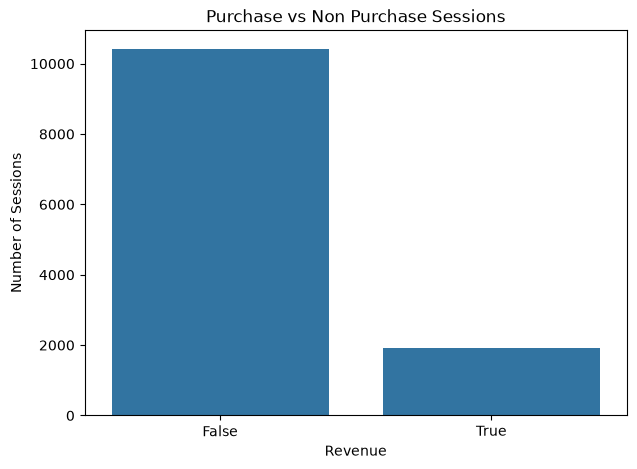

In [42]:
plt.figure(figsize = (7,5))
sns.countplot(data = df, x ="Revenue")

plt.title("Purchase vs Non Purchase Sessions")
plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")

plt.show()



In [50]:
print(f"the unique months we have: {df["Month"].unique()} \n")

print(f"The unique value of the visitor types we have: {df["VisitorType"].unique()}")



the unique months we have: <StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str 

The unique value of the visitor types we have: <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str


In [51]:
revenue_percentage = (
    df["Revenue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

revenue_percentage

Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64

In [57]:
duplicates = df.duplicated().sum()
duplicates

print("\n")

df["Revenue"].value_counts(normalize= True).mul(100).round(2)


Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64

## Univariate Analysis 

Univariate analysis examines the distribution and characterstics of individual variables before investigating realtionhsips between them.

In [59]:
numerical_columns

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType']

In [60]:
continuous_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

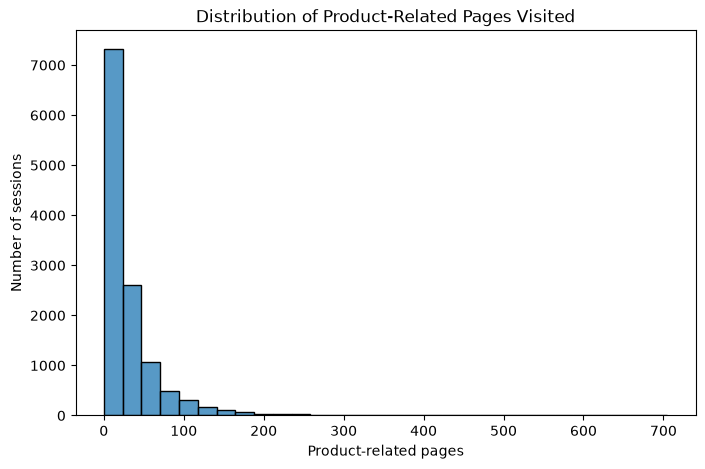

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(data = df, x = "ProductRelated", bins = 30)

plt.title("Distribution of Product-Related Pages Visited")
plt.xlabel("Product-related pages")
plt.ylabel("Number of sessions")

plt.show()

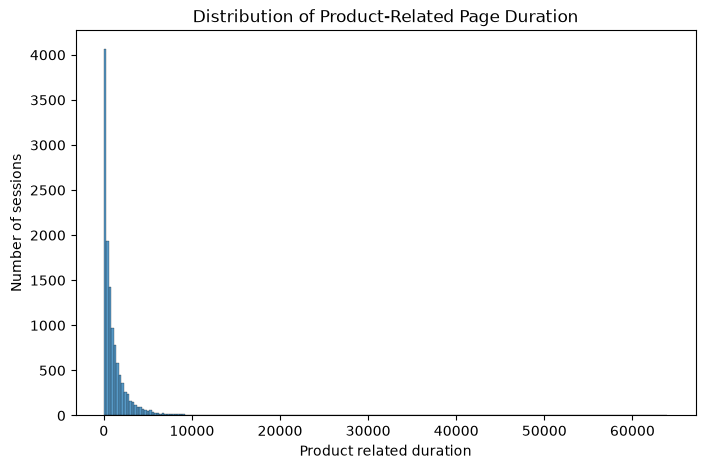

In [64]:
plt.figure(figsize=(8,5))
sns.histplot(data = df, x="ProductRelated_Duration")

plt.title("Distribution of Product-Related Page Duration")
plt.xlabel("Product related duration")
plt.ylabel("Number of sessions")

plt.show()


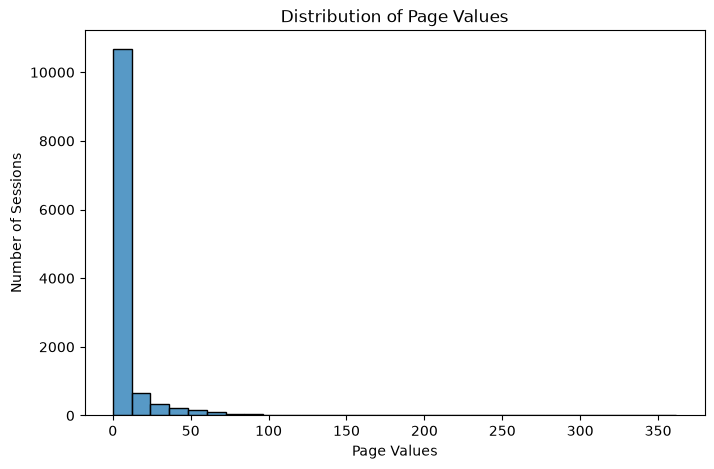

In [65]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="PageValues", bins=30)

plt.title("Distribution of Page Values")
plt.xlabel("Page Values")
plt.ylabel("Number of Sessions")

plt.show()

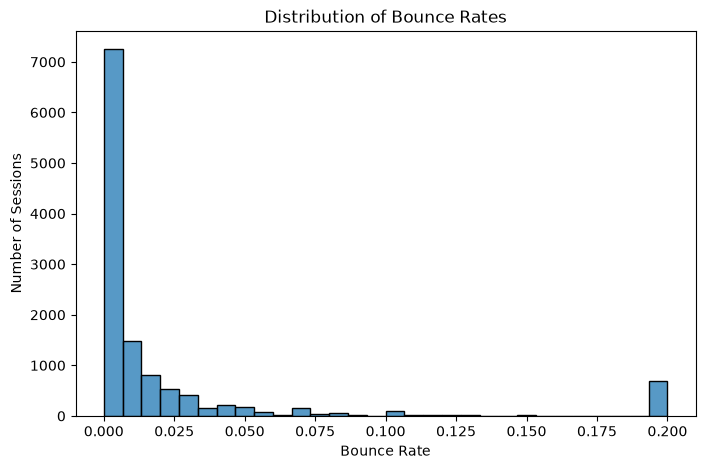

In [67]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="BounceRates", bins=30)

plt.title("Distribution of Bounce Rates")
plt.xlabel("Bounce Rate")
plt.ylabel("Number of Sessions")

plt.show()

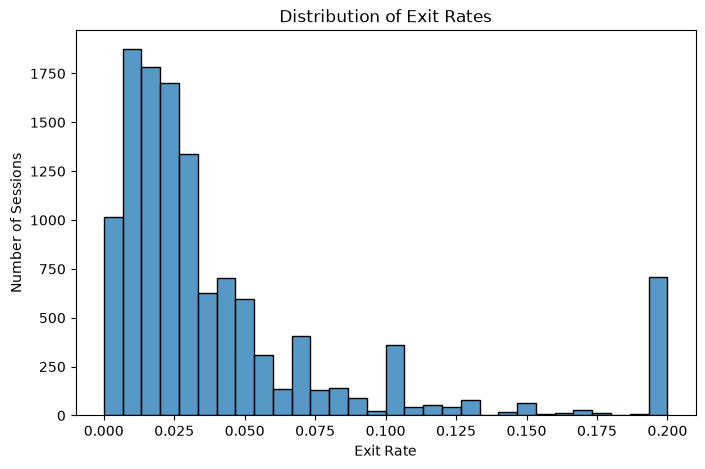

In [68]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="ExitRates", bins=30)

plt.title("Distribution of Exit Rates")
plt.xlabel("Exit Rate")
plt.ylabel("Number of Sessions")

plt.show()


### Observation

The `ProductRelated` variable is concetrated toward lower values, with a smaller number of sessions having substantially higher product-page activity. The distribution appears left-skewed.

In [69]:
skewness = df[continuous_columns].skew().sort_values(ascending=False)

skewness

Informational_Duration     7.579185
ProductRelated_Duration    7.263228
PageValues                 6.382964
Administrative_Duration    5.615719
ProductRelated             4.341516
Informational              4.036464
SpecialDay                 3.302667
BounceRates                2.947855
ExitRates                  2.148789
Administrative             1.960357
dtype: float64

## Outlier Analysis

Outlier analysis is performed to identify unsually large or small observations in numerical variables. Outliers will not be removed automatically, their impact and validity will be investigated before making any cleaning decisions.


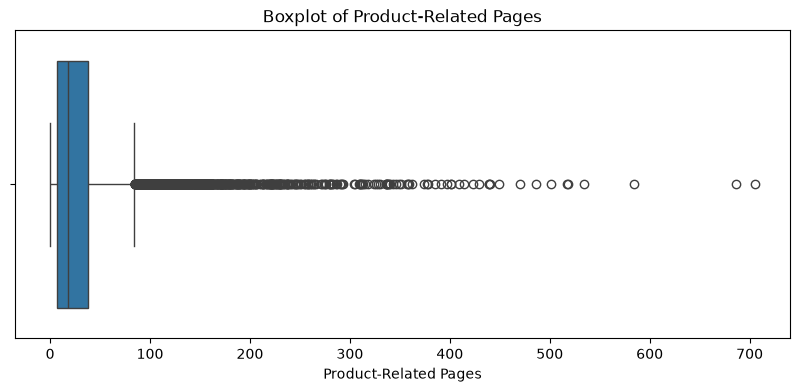

In [70]:
plt.figure(figsize=(10, 4))

sns.boxplot(data=df, x="ProductRelated")

plt.title("Boxplot of Product-Related Pages")
plt.xlabel("Product-Related Pages")

plt.show()

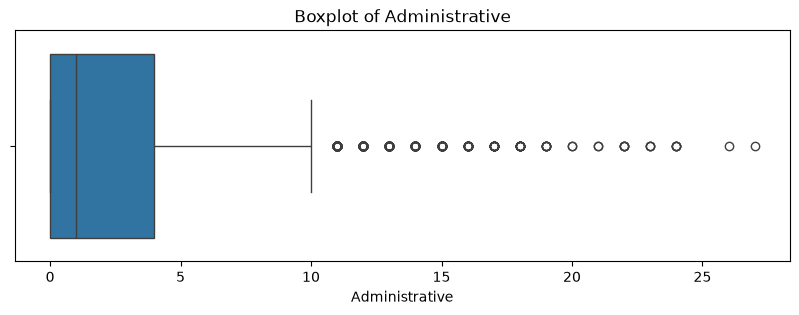

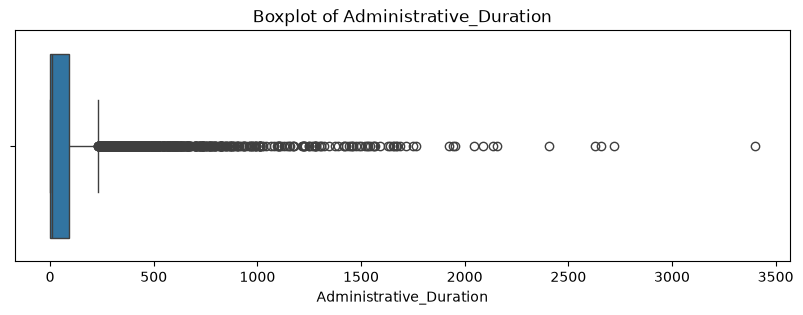

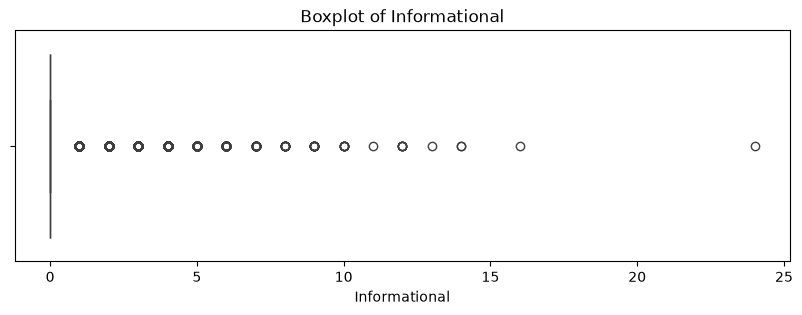

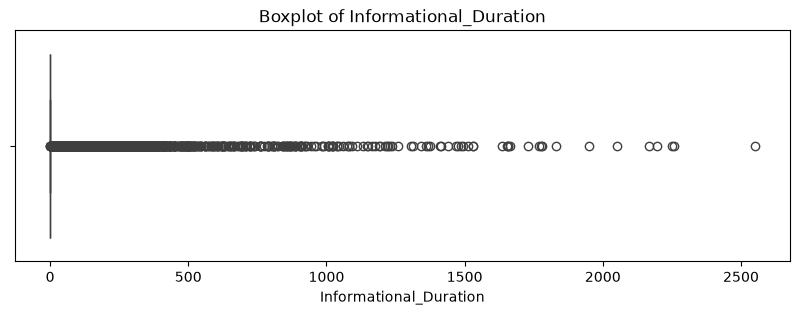

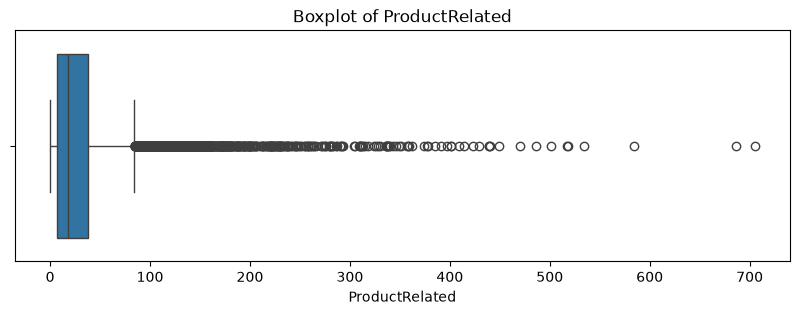

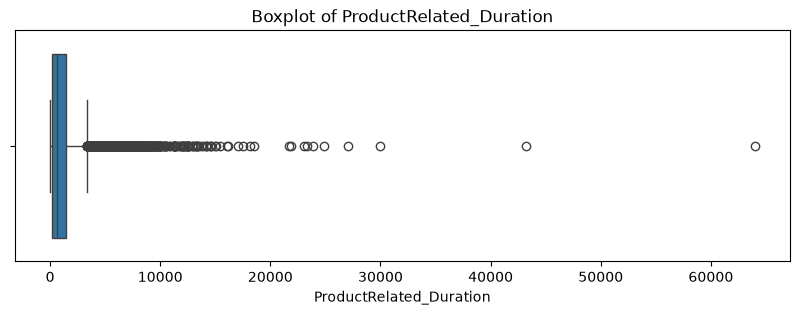

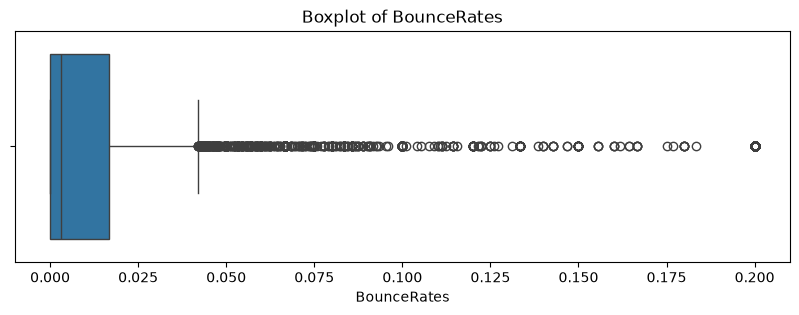

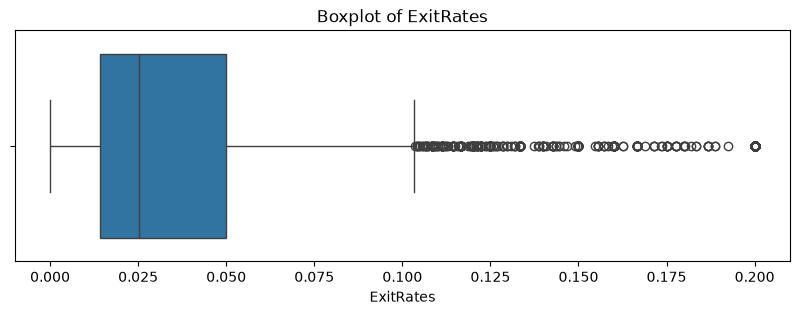

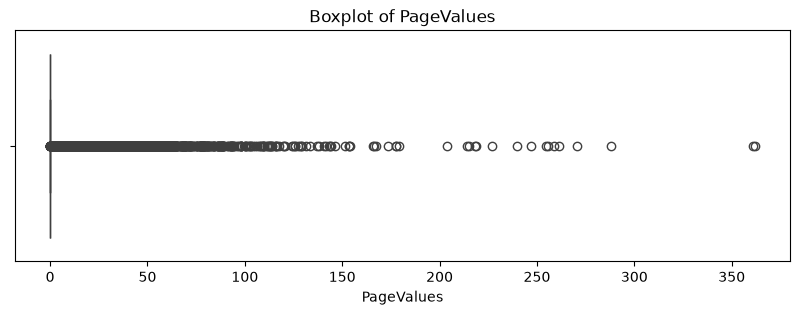

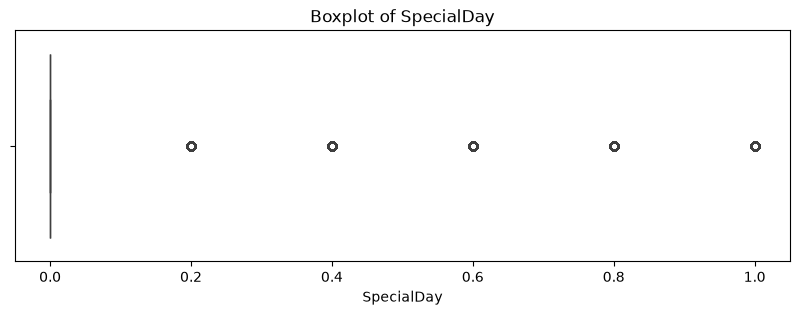

In [71]:
for column in continuous_columns:
    plt.figure(figsize=(10, 3))
    
    sns.boxplot(data=df, x=column)
    
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    
    plt.show()

In [72]:
outlier_summary = []

for column in continuous_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    by="Outlier %",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
8,PageValues,0.000000,0.000000,0.000000,0.000000,0.000000,2730,22.141119
2,Informational,0.000000,0.000000,0.000000,0.000000,0.000000,2631,21.338200
3,Informational_Duration,0.000000,0.000000,0.000000,0.000000,0.000000,2405,19.505272
6,BounceRates,0.000000,0.016813,0.016813,-0.025219,0.042031,1551,12.579075
9,SpecialDay,0.000000,0.000000,0.000000,0.000000,0.000000,1251,10.145985
1,Administrative_Duration,0.000000,93.256250,93.256250,-139.884375,233.140625,1172,9.505272
7,ExitRates,0.014286,0.050000,0.035714,-0.039286,0.103571,1099,8.913220
4,ProductRelated,7.000000,38.000000,31.000000,-39.500000,84.500000,987,8.004866
5,ProductRelated_Duration,184.137500,1464.157214,1280.019714,-1735.892070,3384.186784,961,7.793998
0,Administrative,0.000000,4.000000,4.000000,-6.000000,10.000000,404,3.276561


In [73]:
df[continuous_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [74]:
np.log1p(df["ProductRelated_Duration"])

0        0.000000
1        4.174387
2        0.000000
3        1.299283
4        6.443336
           ...   
12325    7.487057
12326    6.145794
12327    5.221706
12328    5.849325
12329    3.102342
Name: ProductRelated_Duration, Length: 12330, dtype: float64

## Categorical Variable Analysis 

We examine the distribution of categorical variables to understand the compositon of website visitors and their browsing.

In [77]:
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

In [79]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Month
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

OperatingSystems
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64

Browser
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64

Region
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64

TrafficType
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

VisitorType
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                  

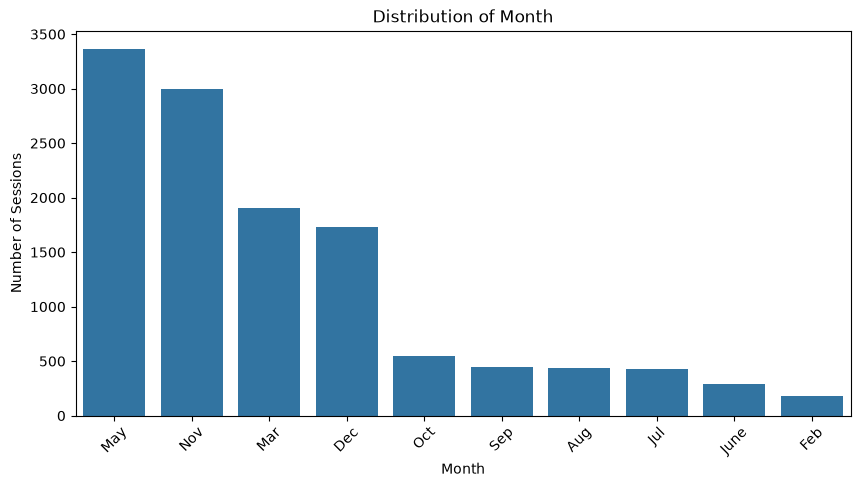

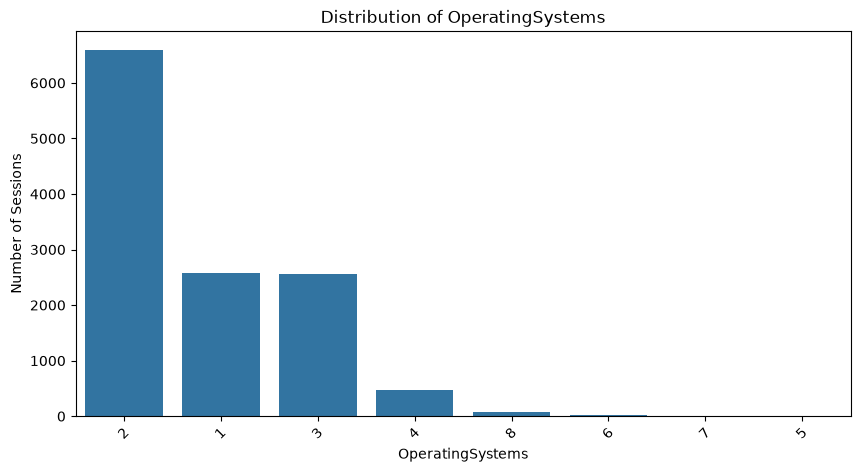

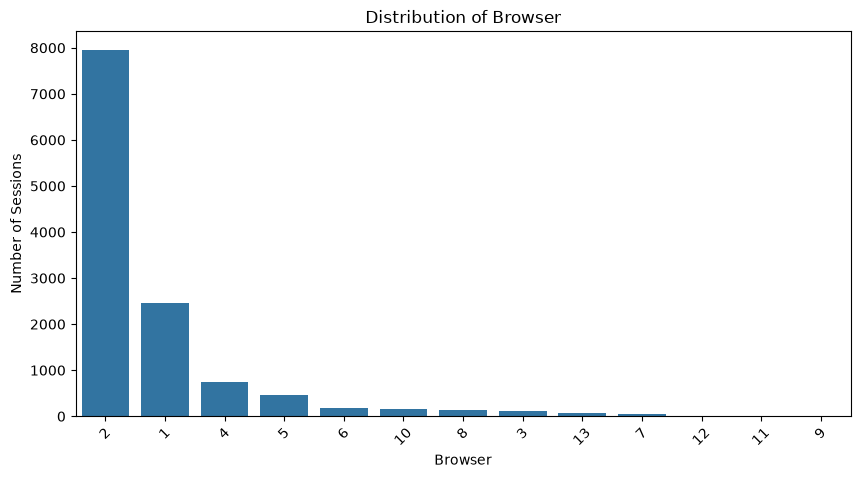

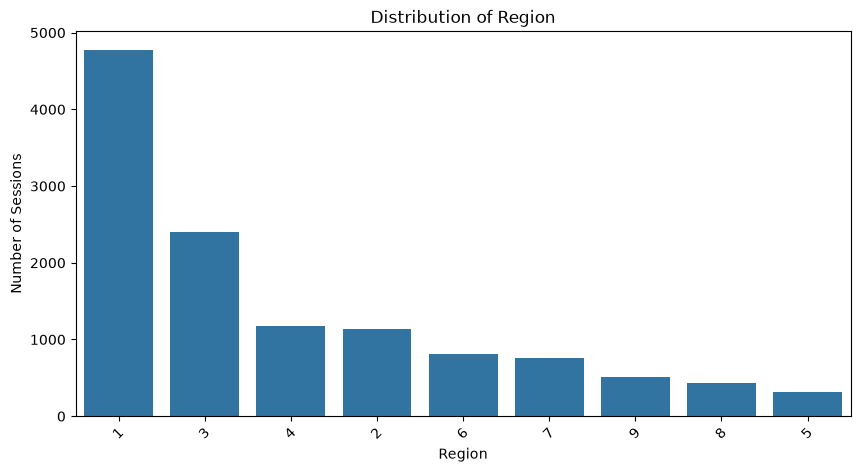

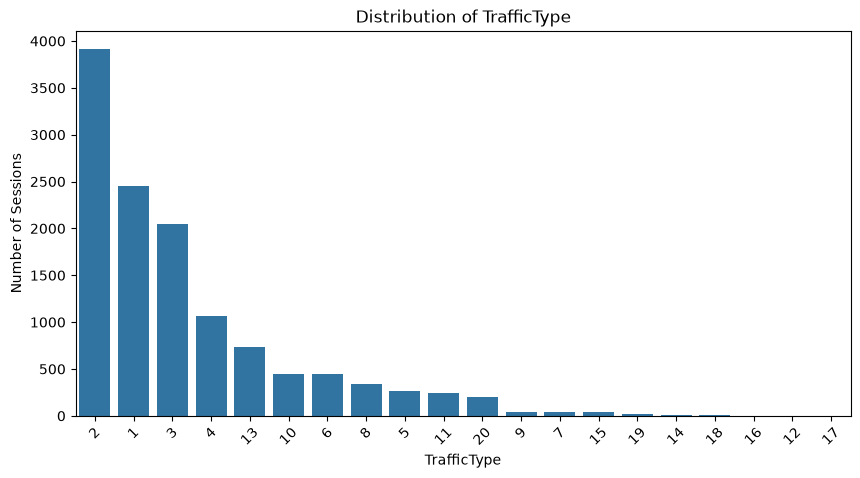

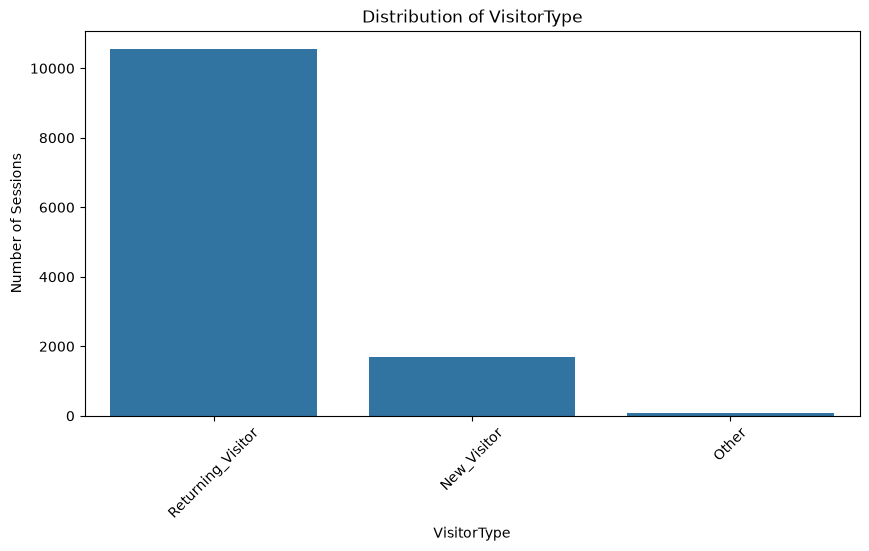

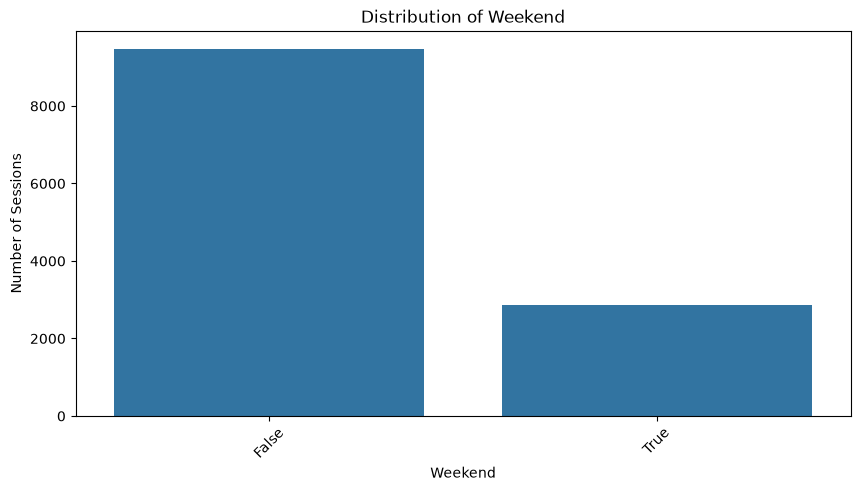

In [80]:
for column in categorical_columns:
    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Sessions")
    plt.xticks(rotation=45)

    plt.show()

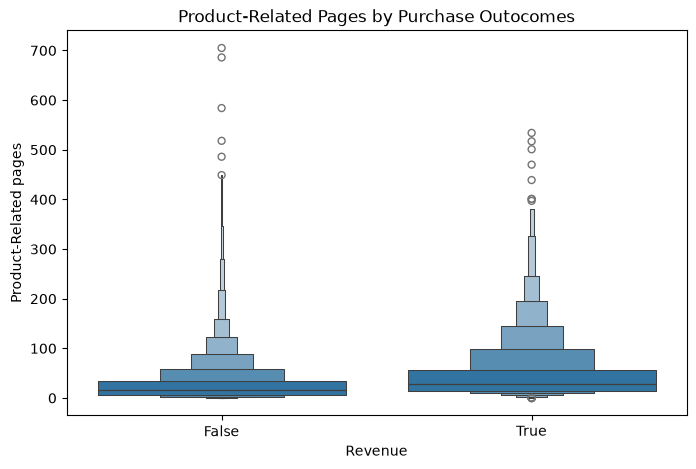

In [81]:
plt.figure(figsize = (8,5))

sns.boxenplot(
    data =df,
    x ="Revenue",
    y = "ProductRelated"
)

plt.title("Product-Related Pages by Purchase Outocomes")
plt.xlabel("Revenue")
plt.ylabel("Product-Related pages")

plt.show()

In [82]:
df.groupby("Revenue")["ProductRelated"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,28.714642,40.744717,0.0,6.0,16.0,35.0,705.0
True,1908.0,48.210168,58.267365,0.0,15.0,29.0,57.0,534.0


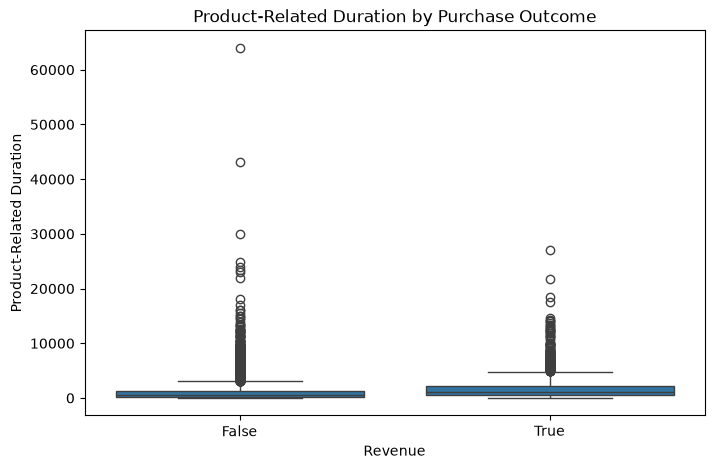

In [83]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated_Duration"
)

plt.title("Product-Related Duration by Purchase Outcome")
plt.xlabel("Revenue")
plt.ylabel("Product-Related Duration")

plt.show()

In [84]:
df.groupby("Revenue")["ProductRelated_Duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1069.987809,1803.797757,0.0,151.00000,510.19000,1331.816667,63973.52223
True,1908.0,1876.209615,2312.214392,0.0,541.90625,1109.90625,2266.011310,27009.85943


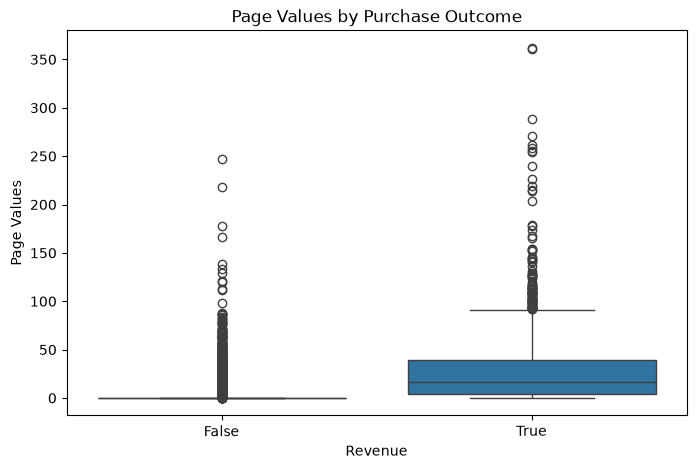

In [85]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="PageValues"
)

plt.title("Page Values by Purchase Outcome")
plt.xlabel("Revenue")
plt.ylabel("Page Values")

plt.show()

In [86]:
df.groupby("Revenue")["PageValues"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1.975998,9.072424,0.0,0.000000,0.000000,0.000000,246.758590
True,1908.0,27.264518,35.191954,0.0,3.641144,16.758134,38.897742,361.763742


In [87]:
revenue_comparison = df.groupby("Revenue")[continuous_columns].mean().T

revenue_comparison

Revenue,False,True
Administrative,2.117732,3.393606
Administrative_Duration,73.740111,119.483244
Informational,0.451833,0.786164
Informational_Duration,30.236237,57.611427
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518
SpecialDay,0.068432,0.023166


In [88]:
revenue_difference = (
    df.groupby("Revenue")[continuous_columns]
      .mean()
      .T
)

revenue_difference["Difference"] = (
    revenue_difference[True] -
    revenue_difference[False]
)

revenue_difference.sort_values(
    "Difference",
    ascending=False
)


Revenue,False,True,Difference
ProductRelated_Duration,1069.987809,1876.209615,806.221806
Administrative_Duration,73.740111,119.483244,45.743133
Informational_Duration,30.236237,57.611427,27.375189
PageValues,1.975998,27.264518,25.288520
ProductRelated,28.714642,48.210168,19.495526
Administrative,2.117732,3.393606,1.275874
Informational,0.451833,0.786164,0.334331
BounceRates,0.025317,0.005117,-0.020200
ExitRates,0.047378,0.019555,-0.027823
SpecialDay,0.068432,0.023166,-0.045267


In [89]:
visitor_revenue = pd.crosstab(
    df["VisitorType"],
    df["Revenue"],
    normalize="index"
) * 100

visitor_revenue

Revenue,False,True
VisitorType,,
New_Visitor,75.088548,24.911452
Other,81.176471,18.823529
Returning_Visitor,86.067671,13.932329


In [90]:
weekend_revenue = pd.crosstab(
    df["Weekend"],
    df["Revenue"],
    normalize="index"
) * 100

weekend_revenue

Revenue,False,True
Weekend,,
False,85.108856,14.891144
True,82.601116,17.398884


In [91]:
month_revenue = pd.crosstab(
    df["Month"],
    df["Revenue"],
    normalize="index"
) * 100

month_revenue

Revenue,False,True
Month,,
Aug,82.448037,17.551963
Dec,87.492762,12.507238
Feb,98.369565,1.630435
Jul,84.722222,15.277778
June,89.930556,10.069444
Mar,89.931830,10.068170
May,89.149822,10.850178
Nov,74.649767,25.350233
Oct,79.052823,20.947177


In [92]:
revenue_difference = (
    df.groupby("Revenue")[continuous_columns]
      .mean()
      .T
)

revenue_difference["Difference"] = (
    revenue_difference[True] -
    revenue_difference[False]
)

revenue_difference.sort_values(
    "Difference",
    ascending=False
)

Revenue,False,True,Difference
ProductRelated_Duration,1069.987809,1876.209615,806.221806
Administrative_Duration,73.740111,119.483244,45.743133
Informational_Duration,30.236237,57.611427,27.375189
PageValues,1.975998,27.264518,25.288520
ProductRelated,28.714642,48.210168,19.495526
Administrative,2.117732,3.393606,1.275874
Informational,0.451833,0.786164,0.334331
BounceRates,0.025317,0.005117,-0.020200
ExitRates,0.047378,0.019555,-0.027823
SpecialDay,0.068432,0.023166,-0.045267


In [93]:
visitor_revenue = pd.crosstab(
    df["VisitorType"],
    df["Revenue"],
    normalize="index"
) * 100

visitor_revenue

Revenue,False,True
VisitorType,,
New_Visitor,75.088548,24.911452
Other,81.176471,18.823529
Returning_Visitor,86.067671,13.932329


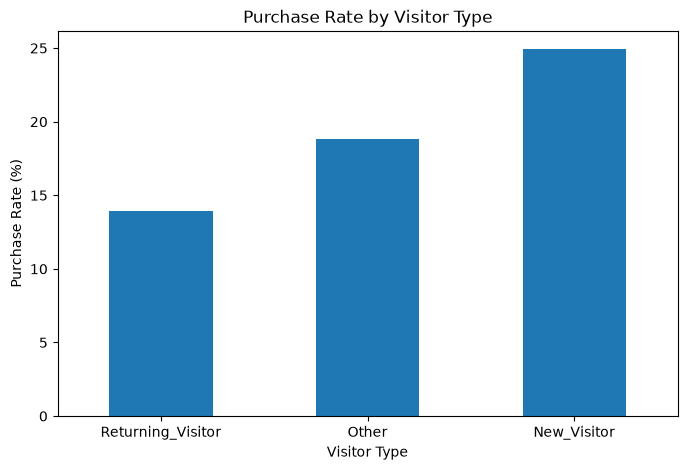

In [94]:
visitor_revenue[True].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Purchase Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [95]:
weekend_revenue = pd.crosstab(
    df["Weekend"],
    df["Revenue"],
    normalize="index"
) * 100

weekend_revenue

Revenue,False,True
Weekend,,
False,85.108856,14.891144
True,82.601116,17.398884


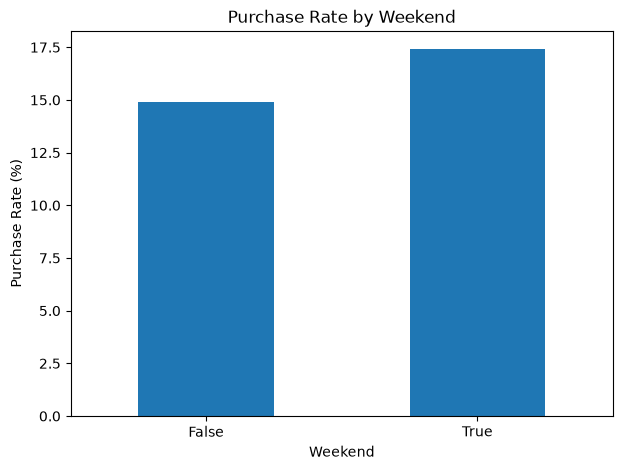

In [96]:
weekend_revenue[True].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Purchase Rate by Weekend")
plt.xlabel("Weekend")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [97]:
month_revenue = pd.crosstab(
    df["Month"],
    df["Revenue"],
    normalize="index"
) * 100

month_revenue

Revenue,False,True
Month,,
Aug,82.448037,17.551963
Dec,87.492762,12.507238
Feb,98.369565,1.630435
Jul,84.722222,15.277778
June,89.930556,10.069444
Mar,89.931830,10.068170
May,89.149822,10.850178
Nov,74.649767,25.350233
Oct,79.052823,20.947177


In [98]:
month_revenue = pd.crosstab(
    df["Month"],
    df["Revenue"],
    normalize="index"
) * 100

month_revenue

Revenue,False,True
Month,,
Aug,82.448037,17.551963
Dec,87.492762,12.507238
Feb,98.369565,1.630435
Jul,84.722222,15.277778
June,89.930556,10.069444
Mar,89.931830,10.068170
May,89.149822,10.850178
Nov,74.649767,25.350233
Oct,79.052823,20.947177


In [99]:
categorical_analysis = {}

for column in [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]:
    categorical_analysis[column] = (
        pd.crosstab(
            df[column],
            df["Revenue"],
            normalize="index"
        ) * 100
    )

    print(f"\n===== {column} =====")
    print(categorical_analysis[column])


===== OperatingSystems =====
Revenue               False      True 
OperatingSystems                      
1                 85.338491  14.661509
2                 82.502651  17.497349
3                 89.510763  10.489237
4                 82.217573  17.782427
5                 83.333333  16.666667
6                 89.473684  10.526316
7                 85.714286  14.285714
8                 78.481013  21.518987

===== Browser =====
Revenue       False      True 
Browser                       
1         85.174655  14.825345
2         84.637608  15.362392
3         95.238095   4.761905
4         82.336957  17.663043
5         81.584582  18.415418
6         88.505747  11.494253
7         87.755102  12.244898
8         84.444444  15.555556
9        100.000000   0.000000
10        80.368098  19.631902
11        83.333333  16.666667
12        70.000000  30.000000
13        73.770492  26.229508

===== Region =====
Revenue      False      True 
Region                       
1        83.87

In [100]:
df_clean = df.copy()

## Data Cleaning

Baased on the findings from exploratory data analysus , the dataset will now be cleaning and validated before feature engineering.

In [101]:
missing_summary = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": df_clean.isnull().mean() * 100
})

missing_summary

,Missing Count,Missing Percentage
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


In [102]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 125


In [103]:
duplicate_percentage = (
    duplicate_count / len(df_clean)
) * 100

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate percentage: 1.01%


In [104]:
duplicates = df_clean[df_clean.duplicated(keep=False)]

duplicates.head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
252,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,False,False
286,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False
293,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
298,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,8,1,Returning_Visitor,False,False
330,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,3,1,Returning_Visitor,False,False


In [105]:
df_without_duplicates = df_clean.drop_duplicates()

print("Before:", df_clean.shape)
print("After :", df_without_duplicates.shape)

Before: (12330, 18)
After : (12205, 18)


In [106]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)
print("Duplicates remaining:", df_clean.duplicated().sum())

Shape after removing duplicates: (12205, 18)
Duplicates remaining: 0


In [108]:
print("Negative values:")
print((df_clean[continuous_columns] < 0).sum())

Negative values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
dtype: int64


In [109]:
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

numerical_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

In [110]:
df_clean.to_csv(
    "data/processed/online_shoppers_clean.csv",
    index=False
)

In [115]:
df_clean[[
    "Administrative",
    "Informational",
    "ProductRelated",
    "TotalPages"
]]

,Administrative,Informational,ProductRelated,TotalPages
0,0,0,1,1
1,0,0,2,2
2,0,0,1,1
3,0,0,2,2
4,0,0,10,10
...,...,...,...,...
12325,3,0,53,56
12326,0,0,5,5
12327,0,0,6,6
12328,4,0,15,19


In [116]:
df_clean["TotalDuration"] = (
    df_clean["Administrative_Duration"]
    + df_clean["Informational_Duration"]
    + df_clean["ProductRelated_Duration"]
)

In [117]:
df_clean.columns.tolist()

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend',
 'Revenue',
 'TotalPages',
 'TotalDuration']

In [119]:
df_clean["TotalDuration"] = (
    df_clean["Administrative_Duration"]
    + df_clean["Informational_Duration"]
    + df_clean["ProductRelated_Duration"]
)



In [120]:
df_clean[
    [
        "Administrative_Duration",
        "Informational_Duration",
        "ProductRelated_Duration",
        "TotalDuration"
    ]
].head()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration,TotalDuration
0,0.0,0.0,0.000000,0.000000
1,0.0,0.0,64.000000,64.000000
2,0.0,0.0,0.000000,0.000000
3,0.0,0.0,2.666667,2.666667
4,0.0,0.0,627.500000,627.500000


In [122]:
df_clean["AvgTimePerPage"] = (
    df_clean["TotalDuration"] / df_clean["TotalPages"].replace(0,np.nan))


In [123]:
df_clean["AvgTimePerPage"].describe()

count    12199.000000
mean        38.197874
std         43.475319
min          0.000000
25%         18.575298
50%         29.992591
75%         45.693714
max       1411.000000
Name: AvgTimePerPage, dtype: float64

In [124]:
df_clean["ProductEngagementRatio"] = (
    df_clean["ProductRelated"]
    / df_clean["TotalPages"].replace(0, np.nan)
)

In [125]:
df_clean["ProductTimeRatio"] = (
    df_clean["ProductRelated_Duration"]
    / df_clean["TotalDuration"].replace(0, np.nan)
)

In [129]:
df_clean[
    [
    "AvgTimePerPage",
    "ProductEngagementRatio",
    "ProductTimeRatio"
]
].isnull().sum()

AvgTimePerPage              6
ProductEngagementRatio      6
ProductTimeRatio          595
dtype: int64

In [131]:
df_clean[
    [
    "AvgTimePerPage",
    "ProductEngagementRatio",
    "ProductTimeRatio"
]
] = df_clean[
    [
    "AvgTimePerPage",
    "ProductEngagementRatio",
    "ProductTimeRatio"
]
].fillna(0)



In [132]:
df_clean[
    [
    "AvgTimePerPage",
    "ProductEngagementRatio",
    "ProductTimeRatio"
]
].isnull().sum()

AvgTimePerPage            0
ProductEngagementRatio    0
ProductTimeRatio          0
dtype: int64

In [133]:
new_features = [
    "TotalPages",
    "TotalDuration",
    "AvgTimePerPage",
    "ProductEngagementRatio",
    "ProductTimeRatio"
]

df_clean[new_features].describe()

,TotalPages,TotalDuration,AvgTimePerPage,ProductEngagementRatio,ProductTimeRatio
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,34.893240,1323.454242,38.179096,0.904126,0.851437
std,46.627336,2043.871589,43.472877,0.142281,0.255850
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,231.666667,18.555556,0.857143,0.831101
50%,20.000000,690.958333,29.970787,0.961538,0.968646
75%,42.000000,1643.958333,45.688278,1.000000,1.000000
max,746.000000,69921.647230,1411.000000,1.000000,1.000000


In [134]:
df_clean.shape

(12205, 23)